# Exercise 2: H₂O Bond-Angle Neural Network


**Target:** Import the libraries and set the random seed.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


**Target:** Define the H₂O bending potential.


In [10]:
import numpy as np

theta_eq = 104.5
k2 = 0.35
k4 = 0.08

def bending_potential(theta_degree):
    # TODO 1: Convert (theta_degree-theta_eq) from degrees to radians.
    delta_theta = np.deg2rad(theta_degree - theta_eq)

    # TODO 2: Return 0.5*k2*delta_theta**2 + k4*delta_theta**4.
    return 0.5 * k2 * delta_theta**2 + k4 * delta_theta**4

**Target:** Generate H–O–H angles and reference energies.


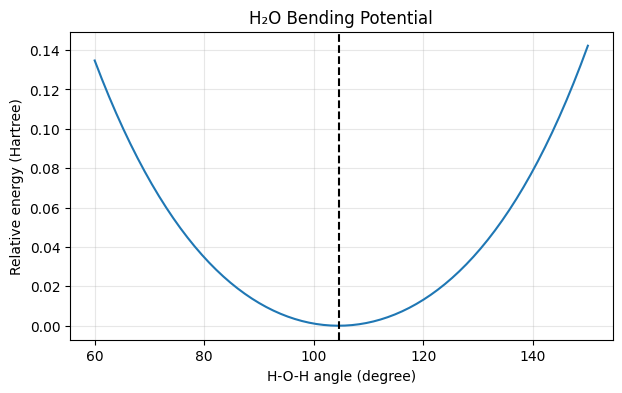

In [11]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.linspace(60.0, 150.0, 70)

# TODO 3: Calculate the reference bending energy for every angle.
energy = bending_potential(theta)

plt.figure(figsize=(7, 4))
plt.plot(theta, energy)
plt.axvline(theta_eq, color="black", linestyle="--")
plt.xlabel("H-O-H angle (degree)")
plt.ylabel("Relative energy (Hartree)")
plt.title("H₂O Bending Potential")
plt.grid(alpha=0.3)
plt.show()

**Target:** Create training and test sets.


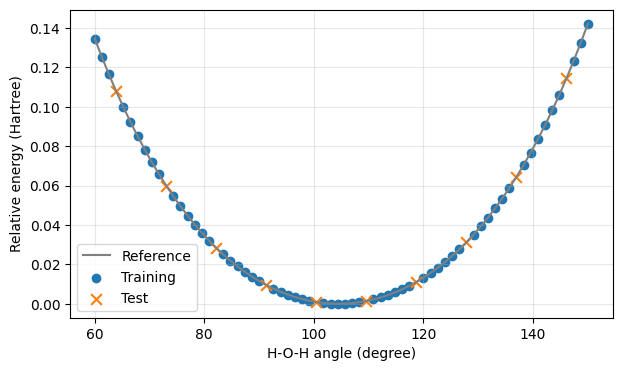

In [12]:
import numpy as np
import matplotlib.pyplot as plt

test_idx = np.arange(3, len(theta), 7)
train_idx = np.array([i for i in range(len(theta)) if i not in test_idx])

# TODO 4: Select the training and test values.
theta_train, energy_train = theta[train_idx], energy[train_idx]
theta_test, energy_test = theta[test_idx], energy[test_idx]

plt.figure(figsize=(7, 4))
plt.plot(theta, energy, color="gray", label="Reference")
plt.scatter(theta_train, energy_train, label="Training")
plt.scatter(theta_test, energy_test, marker="x", s=60, label="Test")
plt.xlabel("H-O-H angle (degree)")
plt.ylabel("Relative energy (Hartree)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Target:** Normalize the angles and energies.


In [13]:
import numpy as np

# TODO 5: Calculate means and standard deviations from the training set.
theta_mean, theta_std = np.mean(theta_train), np.std(theta_train)
energy_mean, energy_std = np.mean(energy_train), np.std(energy_train)

# TODO 6: Normalize the training and test arrays and reshape them to (N, 1).
X_train = ((theta_train - theta_mean) / theta_std).reshape(-1, 1)
y_train = ((energy_train - energy_mean) / energy_std).reshape(-1, 1)
X_test = ((theta_test - theta_mean) / theta_std).reshape(-1, 1)
y_test = ((energy_test - energy_mean) / energy_std).reshape(-1, 1)

**Target:** Build the neural network.


In [14]:
import numpy as np

def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1.0 - np.tanh(z)**2

class SimpleNN:
    def __init__(self, n_hidden=32):
        scale1 = np.sqrt(2.0 / (1 + n_hidden))
        scale2 = np.sqrt(2.0 / (n_hidden + 1))

        self.W1 = np.random.randn(1, n_hidden) * scale1
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.randn(n_hidden, 1) * scale2
        self.b2 = np.zeros((1, 1))
        self.cache = {}

    def forward(self, X):
        # TODO 7: Calculate z1, a1, and y_pred.
        z1 = np.dot(X, self.W1) + self.b1
        a1 = tanh(z1)
        y_pred = np.dot(a1, self.W2) + self.b2
        self.cache = {"X": X, "z1": z1, "a1": a1}
        return y_pred

    def loss(self, y_pred, y_true):
        # TODO 8: Return the mean squared error.
        return np.mean((y_pred - y_true)**2)

    def backward(self, y_pred, y_true):
        X = self.cache["X"]
        z1 = self.cache["z1"]
        a1 = self.cache["a1"]
        n = len(X)

        # TODO 9: Complete backpropagation.
        d_y = 2 * (y_pred - y_true) / n
        dW2 = np.dot(a1.T, d_y)
        db2 = np.sum(d_y, axis=0, keepdims=True)
        d_z1 = np.dot(d_y, self.W2.T) * tanh_derivative(z1)
        dW1 = np.dot(X.T, d_z1)
        db1 = np.sum(d_z1, axis=0, keepdims=True)

        return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

**Target:** Train the neural network.


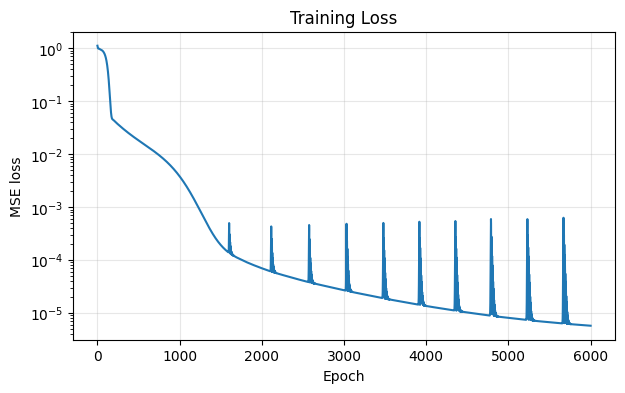

In [15]:
import numpy as np
import matplotlib.pyplot as plt

class Adam:
    def __init__(self, learning_rate=0.003, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = {}
        self.v = {}
        self.t = 0

    def step(self, model, gradients):
        self.t += 1

        for name in ["W1", "b1", "W2", "b2"]:
            gradient = gradients["d" + name]
            parameter = getattr(model, name)

            if name not in self.m:
                self.m[name] = np.zeros_like(parameter)
                self.v[name] = np.zeros_like(parameter)

            self.m[name] = self.beta1*self.m[name] + (1-self.beta1)*gradient
            self.v[name] = self.beta2*self.v[name] + (1-self.beta2)*gradient**2

            m_corrected = self.m[name] / (1-self.beta1**self.t)
            v_corrected = self.v[name] / (1-self.beta2**self.t)
            parameter -= self.learning_rate*m_corrected/(np.sqrt(v_corrected) + self.epsilon)


def train(model, X_train, y_train, epochs=6000, learning_rate=0.003):
    optimizer = Adam(learning_rate=learning_rate)
    losses = []

    for epoch in range(epochs):
        y_pred = model.forward(X_train)
        loss = model.loss(y_pred, y_train)
        gradients = model.backward(y_pred, y_train)

        # TODO 10: Use the optimizer to update the model parameters.
        optimizer.step(model, gradients)

        losses.append(loss)

    return losses


np.random.seed(42)
model = SimpleNN(n_hidden=32)
losses = train(model, X_train, y_train)

plt.figure(figsize=(7, 4))
plt.semilogy(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training Loss")
plt.grid(alpha=0.3)
plt.show()

**Target:** Evaluate the model on unseen bond angles.


In [7]:
import numpy as np

# TODO 11: Predict normalized test energies and convert them to Hartree.
test_prediction_n = model.forward(X_test)
test_prediction = test_prediction_n * energy_std + energy_mean

# TODO 12: Calculate the test RMSE in Hartree and kcal/mol.
rmse_hartree = np.sqrt(np.mean((test_prediction - energy_test)**2))
rmse_kcal = rmse_hartree * 627.509

print(f"Test RMSE: {rmse_hartree:.6f} Hartree")
print(f"Test RMSE: {rmse_kcal:.2f} kcal/mol")

Test RMSE: 0.056730 Hartree
Test RMSE: 35.60 kcal/mol


**Target:** Plot the learned H₂O bending-energy curve.


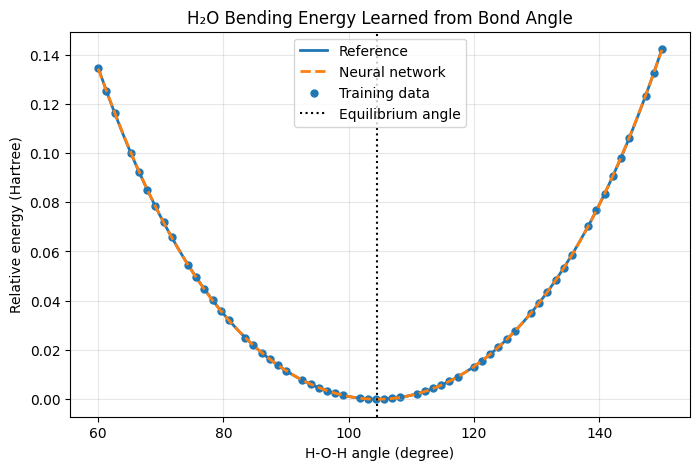

In [8]:
import numpy as np
import matplotlib.pyplot as plt

theta_dense = np.linspace(60.0, 150.0, 400)

# TODO 13: Normalize theta_dense, predict its energies, and denormalize them.
X_dense = ((theta_dense - theta_mean) / theta_std).reshape(-1, 1)
energy_prediction_n = model.forward(X_dense)
energy_prediction = energy_prediction_n * energy_std + energy_mean

plt.figure(figsize=(8, 5))
plt.plot(theta_dense, bending_potential(theta_dense), linewidth=2, label="Reference")
plt.plot(theta_dense, energy_prediction, "--", linewidth=2, label="Neural network")
plt.scatter(theta_train, energy_train, s=25, label="Training data")
plt.axvline(theta_eq, color="black", linestyle=":", label="Equilibrium angle")
plt.xlabel("H-O-H angle (degree)")
plt.ylabel("Relative energy (Hartree)")
plt.title("H₂O Bending Energy Learned from Bond Angle")
plt.legend()
plt.grid(alpha=0.3)
plt.show()